In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Helper functions
def vcol(x):
    """Convert vector to column vector"""
    return x.reshape(x.size, 1)

def vrow(x):
    """Convert vector to row vector"""
    return x.reshape(1, x.size)

# Data loading and preparation
def load_project_data(file_path="trainData.txt"):
    """Load the project data from file"""
    data_list = []
    labels = []

    with open(file_path, 'r') as f:
        for line in f:
            values = line.strip().split(',')
            features = [float(v.strip()) for v in values[:-1]]
            label = int(float(values[-1].strip()))

            data_list.append(features)
            labels.append(label)

    # Convert to numpy arrays with features as rows
    data = np.array(data_list).T
    labels = np.array(labels)

    return data, labels

def split_db_2to1(D, L, seed=0):
    """Split dataset in 2:1 ratio (training:testing)"""
    nTrain = int(D.shape[1]*2.0/3.0)
    np.random.seed(seed)
    idx = np.random.permutation(D.shape[1])
    idxTrain = idx[0:nTrain]
    idxTest = idx[nTrain:]
    DTR = D[:, idxTrain]
    DTE = D[:, idxTest]
    LTR = L[idxTrain]
    LTE = L[idxTest]
    return (DTR, LTR), (DTE, LTE)

In [12]:
def compute_class_parameters(DTR, LTR):
    """Compute ML estimates of mean and covariance for each class"""
    classes = np.unique(LTR)
    mu_dict = {}
    sigma_dict = {}

    for c in classes:
        # Extract samples for class c
        X_c = DTR[:, LTR == c]

        # Compute mean vector
        mu_c = X_c.mean(1).reshape((X_c.shape[0], 1))

        # Compute covariance matrix
        centered_data = X_c - mu_c
        sigma_c = np.dot(centered_data, centered_data.T) / X_c.shape[1]

        mu_dict[c] = mu_c
        sigma_dict[c] = sigma_c

    return mu_dict, sigma_dict

def logpdf_GAU_ND(X, mu, Sigma):
    """Compute log-density of multivariate Gaussian"""
    M = X.shape[0]  # Feature dimensionality
    const = -0.5 * M * np.log(2*np.pi)
    sign, logdet = np.linalg.slogdet(Sigma)
    inv_sigma = np.linalg.inv(Sigma)

    log_densities = np.zeros(X.shape[1])
    for i in range(X.shape[1]):
        xc = X[:, i:i+1] - mu
        log_densities[i] = const - 0.5 * logdet - 0.5 * np.dot(np.dot(xc.T, inv_sigma), xc)

    return log_densities

def compute_log_densities(X, mu_dict, sigma_dict):
    """Compute log-densities for all classes"""
    S = np.zeros((len(mu_dict), X.shape[1]))

    for c in mu_dict.keys():
        S[c, :] = logpdf_GAU_ND(X, mu_dict[c], sigma_dict[c])

    return S

def compute_llr(S):
    """Compute log-likelihood ratio: log(p(x|c=1)/p(x|c=0))"""
    return S[1, :] - S[0, :]

def predictions_from_llr(llr, threshold=0):
    """Make predictions from log-likelihood ratios using threshold"""
    return (llr > threshold).astype(int)

def compute_error_rate(predictions, ground_truth):
    """Compute error rate"""
    return (predictions != ground_truth).mean()

In [13]:
def naive_bayes_params(mu_dict, sigma_dict):
    """Create Naive Bayes parameters by zeroing off-diagonal elements"""
    mu_NB = mu_dict.copy()
    sigma_NB = {}

    for c in mu_dict.keys():
        # Zero out off-diagonal elements
        sigma_NB[c] = sigma_dict[c] * np.eye(sigma_dict[c].shape[0])

    return mu_NB, sigma_NB

def tied_cov_params(mu_dict, sigma_dict, DTR, LTR):
    """Compute tied covariance matrix"""
    mu_tied = mu_dict.copy()
    sigma_tied = np.zeros_like(sigma_dict[0])
    N = DTR.shape[1]

    for c in mu_dict.keys():
        nc = np.sum(LTR == c)
        sigma_tied += (nc / N) * sigma_dict[c]

    # Use same covariance for all classes
    sigma_tied_dict = {c: sigma_tied for c in mu_dict.keys()}

    return mu_tied, sigma_tied_dict

In [14]:
def compute_correlation_matrix(sigma):
    """Compute correlation matrix from covariance matrix"""
    diag_sqrt = np.sqrt(np.diag(sigma))
    corr = sigma / np.outer(diag_sqrt, diag_sqrt)
    return corr

def analyze_correlation_matrices(sigma_dict):
    """Analyze correlation matrices to understand feature relationships"""
    corr_dict = {}

    for c in sigma_dict.keys():
        sigma = sigma_dict[c]
        # Compute correlation matrix
        corr = compute_correlation_matrix(sigma)
        corr_dict[c] = corr

        print(f"Correlation matrix for class {c}:")
        print(corr)

        # Highlight strong correlations
        for i in range(corr.shape[0]):
            for j in range(i+1, corr.shape[0]):
                if abs(corr[i, j]) > 0.5:
                    print(f"Strong correlation between features {i} and {j}: {corr[i, j]:.2f}")

    return corr_dict

def test_feature_subsets(D, L):
    """Test classification with different feature subsets"""
    subsets = {
        "Features 0-1": D[0:2, :],
        "Features 2-3": D[2:4, :],
        "Features 4-5": D[4:6, :],
        "Features 0-3": D[0:4, :],
        "All Features": D
    }

    results = {}

    for name, D_sub in subsets.items():
        print(f"\nTesting {name}:")

        # Split data
        (DTR_sub, LTR_sub), (DTE_sub, LTE_sub) = split_db_2to1(D_sub, L)

        # MVG classifier
        mu_mvg, sigma_mvg = compute_class_parameters(DTR_sub, LTR_sub)
        S_mvg = compute_log_densities(DTE_sub, mu_mvg, sigma_mvg)
        llr_mvg = compute_llr(S_mvg)
        pred_mvg = predictions_from_llr(llr_mvg)
        err_mvg = compute_error_rate(pred_mvg, LTE_sub)

        # Naive Bayes classifier
        mu_nb, sigma_nb = naive_bayes_params(mu_mvg, sigma_mvg)
        S_nb = compute_log_densities(DTE_sub, mu_nb, sigma_nb)
        llr_nb = compute_llr(S_nb)
        pred_nb = predictions_from_llr(llr_nb)
        err_nb = compute_error_rate(pred_nb, LTE_sub)

        # Tied Covariance classifier
        mu_tied, sigma_tied = tied_cov_params(mu_mvg, sigma_mvg, DTR_sub, LTR_sub)
        S_tied = compute_log_densities(DTE_sub, mu_tied, sigma_tied)
        llr_tied = compute_llr(S_tied)
        pred_tied = predictions_from_llr(llr_tied)
        err_tied = compute_error_rate(pred_tied, LTE_sub)

        print(f"MVG Error Rate: {err_mvg*100:.1f}%")
        print(f"Naive Bayes Error Rate: {err_nb*100:.1f}%")
        print(f"Tied Covariance Error Rate: {err_tied*100:.1f}%")

        results[name] = {
            'MVG': err_mvg,
            'NB': err_nb,
            'TC': err_tied
        }

    return results

def apply_pca(DTR, DTE, n_components=2):
    """Apply PCA dimensionality reduction"""
    pca = PCA(n_components=n_components)
    pca.fit(DTR.T)  # Fit on training data

    # Transform both training and test data
    DTR_pca = pca.transform(DTR.T).T
    DTE_pca = pca.transform(DTE.T).T

    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

    return DTR_pca, DTE_pca

In [15]:
def plot_feature_distributions(D, L):
    """Plot distributions of features by class"""
    feature_names = [f"Feature {i}" for i in range(D.shape[0])]
    class_names = ["Class 0", "Class 1"]
    colors = ["aqua", "orange"]

    # Create a figure with subplots for each feature
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i in range(min(D.shape[0], len(axes))):
        ax = axes[i]

        # Plot histogram for each class
        for c in range(2):
            class_data = D[i, L == c]
            ax.hist(class_data, bins=15, alpha=0.5, label=class_names[c], color=colors[c])

        ax.set_title(feature_names[i])
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_llr_histograms(llr, labels):
    """Plot histograms of log-likelihood ratios by class"""
    plt.figure(figsize=(10, 6))

    # Plot LLR for class 0
    plt.hist(llr[labels == 0], bins=15, alpha=0.5, label="Class 0", color="aqua")

    # Plot LLR for class 1
    plt.hist(llr[labels == 1], bins=15, alpha=0.5, label="Class 1", color="orange")

    plt.axvline(x=0, color='black', linestyle='--', label="Threshold (t=0)")

    plt.title("Log-Likelihood Ratio Distributions")
    plt.xlabel("LLR Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Loading project data...
Dataset loaded: 6 features, 6000 samples
Training set: 4000 samples
Validation set: 2000 samples


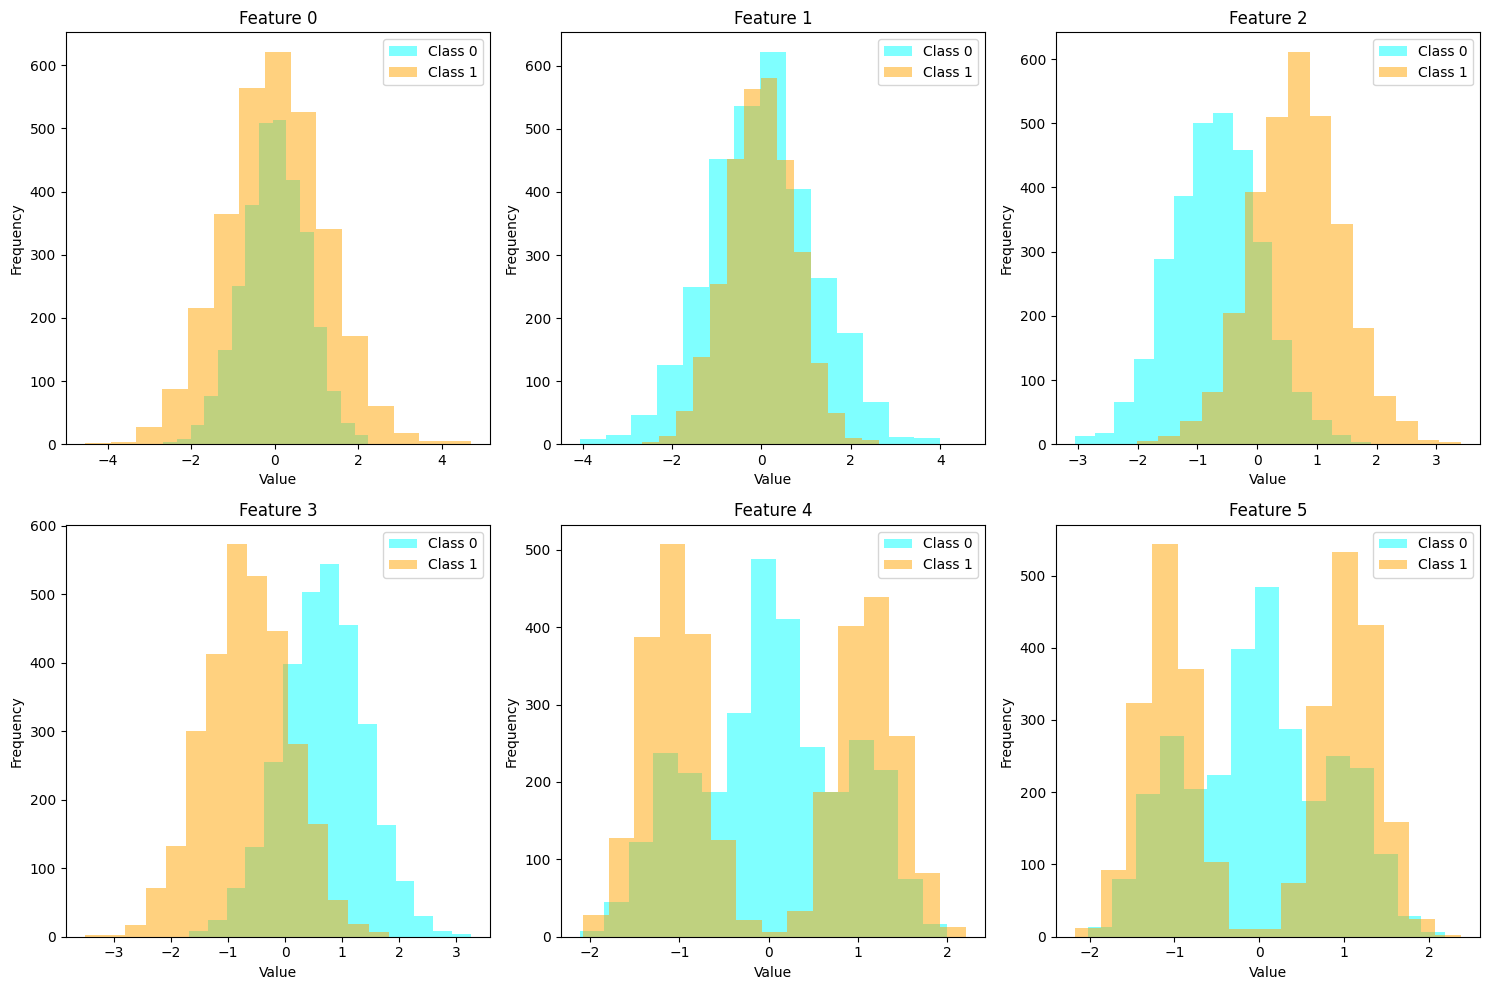


===== Multivariate Gaussian Classifier =====

Class 0 parameters:
Mean (μ_0):
[-0.00652448  0.01606322 -0.6740945   0.68051603  0.01566136 -0.01328887]
Covariance matrix (Σ_0):
[[ 6.00956506e-01  5.15866517e-05  1.90589145e-02  1.92529876e-02
   1.28039402e-02 -1.34721598e-02]
 [ 5.15866517e-05  1.44722543e+00 -1.61340110e-02 -1.58561474e-02
  -2.64529141e-02  2.29139833e-02]
 [ 1.90589145e-02 -1.61340110e-02  5.65348901e-01 -1.84344435e-03
  -6.91446277e-03  1.68928322e-02]
 [ 1.92529876e-02 -1.58561474e-02 -1.84344435e-03  5.41615202e-01
   5.25171375e-03  1.35717775e-02]
 [ 1.28039402e-02 -2.64529141e-02 -6.91446277e-03  5.25171375e-03
   6.96067641e-01  1.58438399e-02]
 [-1.34721598e-02  2.29139833e-02  1.68928322e-02  1.35717775e-02
   1.58438399e-02  6.86519710e-01]]

Class 1 parameters:
Mean (μ_1):
[-0.00470503 -0.00937712  0.65595642 -0.65899208 -0.04389535  0.02496486]
Covariance matrix (Σ_1):
[[ 1.44809527e+00 -1.47222433e-02  5.57010301e-03  1.57415883e-02
   1.94971163e-02

C:\Users\marca\AppData\Local\Temp\ipykernel_18984\1436415138.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_densities[i] = const - 0.5 * logdet - 0.5 * np.dot(np.dot(xc.T, inv_sigma), xc)


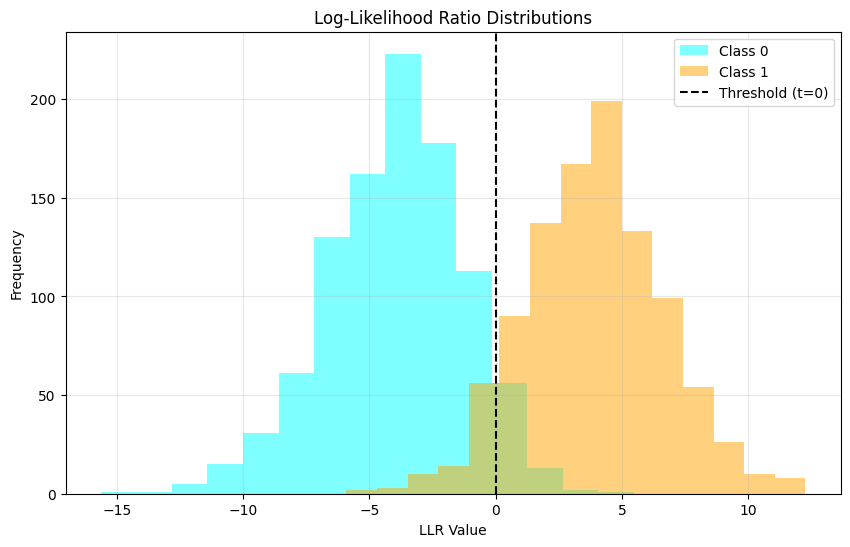


===== Naive Bayes Gaussian Classifier =====
Naive Bayes Error Rate: 7.2%

===== Tied Covariance Gaussian Classifier =====
Tied Covariance Matrix:
[[ 1.02494946 -0.00734272  0.01230776  0.01749553  0.01615387 -0.00681777]
 [-0.00734272  0.99986119 -0.01367298 -0.01245704 -0.02055006  0.01962831]
 [ 0.01230776 -0.01367298  0.56141063  0.01287346 -0.00534049  0.00113182]
 [ 0.01749553 -0.01245704  0.01287346  0.55565013 -0.00323179  0.02429319]
 [ 0.01615387 -0.02055006 -0.00534049 -0.00323179  1.01936563  0.01639518]
 [-0.00681777  0.01962831  0.00113182  0.02429319  0.01639518  0.99542786]]
Tied Covariance Error Rate: 9.3%

===== Correlation Analysis =====
Correlation matrix for class 0:
[[ 1.00000000e+00  5.53156127e-05  3.26977873e-02  3.37466904e-02
   1.97968638e-02 -2.09743833e-02]
 [ 5.53156127e-05  1.00000000e+00 -1.78367604e-02 -1.79095288e-02
  -2.63560127e-02  2.29882544e-02]
 [ 3.26977873e-02 -1.78367604e-02  1.00000000e+00 -3.33139656e-03
  -1.10223563e-02  2.71155043e-02]


C:\Users\marca\AppData\Local\Temp\ipykernel_18984\1436415138.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_densities[i] = const - 0.5 * logdet - 0.5 * np.dot(np.dot(xc.T, inv_sigma), xc)
C:\Users\marca\AppData\Local\Temp\ipykernel_18984\1436415138.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_densities[i] = const - 0.5 * logdet - 0.5 * np.dot(np.dot(xc.T, inv_sigma), xc)


In [16]:
def project_implementation():
    """Complete project implementation"""
    # Load data
    print("Loading project data...")
    D, L = load_project_data("../lab_2/trainData.txt")
    print(f"Dataset loaded: {D.shape[0]} features, {D.shape[1]} samples")

    # Split into training and validation sets
    (DTR, LTR), (DTE, LTE) = split_db_2to1(D, L)
    print(f"Training set: {DTR.shape[1]} samples")
    print(f"Validation set: {DTE.shape[1]} samples")

    # Visualize feature distributions
    plot_feature_distributions(D, L)

    # MVG classifier
    print("\n===== Multivariate Gaussian Classifier =====")
    mu_mvg, sigma_mvg = compute_class_parameters(DTR, LTR)

    # Print parameters for each class
    for c in [0, 1]:
        print(f"\nClass {c} parameters:")
        print(f"Mean (μ_{c}):")
        print(mu_mvg[c].reshape(-1))
        print(f"Covariance matrix (Σ_{c}):")
        print(sigma_mvg[c])

    S_mvg = compute_log_densities(DTE, mu_mvg, sigma_mvg)
    llr_mvg = compute_llr(S_mvg)
    pred_mvg = predictions_from_llr(llr_mvg)
    err_mvg = compute_error_rate(pred_mvg, LTE)
    print(f"MVG Error Rate: {err_mvg*100:.1f}%")

    # Visualize LLR distributions
    plot_llr_histograms(llr_mvg, LTE)

    # Naive Bayes classifier
    print("\n===== Naive Bayes Gaussian Classifier =====")
    mu_nb, sigma_nb = naive_bayes_params(mu_mvg, sigma_mvg)
    S_nb = compute_log_densities(DTE, mu_nb, sigma_nb)
    llr_nb = compute_llr(S_nb)
    pred_nb = predictions_from_llr(llr_nb)
    err_nb = compute_error_rate(pred_nb, LTE)
    print(f"Naive Bayes Error Rate: {err_nb*100:.1f}%")

    # Tied Covariance classifier
    print("\n===== Tied Covariance Gaussian Classifier =====")
    mu_tied, sigma_tied = tied_cov_params(mu_mvg, sigma_mvg, DTR, LTR)
    print("Tied Covariance Matrix:")
    print(sigma_tied[0])
    S_tied = compute_log_densities(DTE, mu_tied, sigma_tied)
    llr_tied = compute_llr(S_tied)
    pred_tied = predictions_from_llr(llr_tied)
    err_tied = compute_error_rate(pred_tied, LTE)
    print(f"Tied Covariance Error Rate: {err_tied*100:.1f}%")

    # Correlation analysis
    print("\n===== Correlation Analysis =====")
    corr_dict = analyze_correlation_matrices(sigma_mvg)

    # Feature subset analysis
    print("\n===== Feature Subset Analysis =====")
    subset_results = test_feature_subsets(D, L)

    # PCA analysis
    print("\n===== PCA Analysis =====")
    for n_components in [2, 4]:
        print(f"\nPCA with {n_components} components:")
        DTR_pca, DTE_pca = apply_pca(DTR, DTE, n_components=n_components)

        # MVG with PCA
        mu_mvg_pca, sigma_mvg_pca = compute_class_parameters(DTR_pca, LTR)
        S_mvg_pca = compute_log_densities(DTE_pca, mu_mvg_pca, sigma_mvg_pca)
        llr_mvg_pca = compute_llr(S_mvg_pca)
        pred_mvg_pca = predictions_from_llr(llr_mvg_pca)
        err_mvg_pca = compute_error_rate(pred_mvg_pca, LTE)

        # Naive Bayes with PCA
        mu_nb_pca, sigma_nb_pca = naive_bayes_params(mu_mvg_pca, sigma_mvg_pca)
        S_nb_pca = compute_log_densities(DTE_pca, mu_nb_pca, sigma_nb_pca)
        llr_nb_pca = compute_llr(S_nb_pca)
        pred_nb_pca = predictions_from_llr(llr_nb_pca)
        err_nb_pca = compute_error_rate(pred_nb_pca, LTE)

        # Tied Covariance with PCA
        mu_tied_pca, sigma_tied_pca = tied_cov_params(mu_mvg_pca, sigma_mvg_pca, DTR_pca, LTR)
        S_tied_pca = compute_log_densities(DTE_pca, mu_tied_pca, sigma_tied_pca)
        llr_tied_pca = compute_llr(S_tied_pca)
        pred_tied_pca = predictions_from_llr(llr_tied_pca)
        err_tied_pca = compute_error_rate(pred_tied_pca, LTE)

        print(f"MVG Error Rate with PCA: {err_mvg_pca*100:.1f}%")
        print(f"Naive Bayes Error Rate with PCA: {err_nb_pca*100:.1f}%")
        print(f"Tied Covariance Error Rate with PCA: {err_tied_pca*100:.1f}%")

    # Results summary
    print("\n===== Summary =====")
    print(f"MVG Error Rate: {err_mvg*100:.1f}%")
    print(f"Naive Bayes Error Rate: {err_nb*100:.1f}%")
    print(f"Tied Covariance Error Rate: {err_tied*100:.1f}%")

    # Find best model
    best_model = min(
        [("MVG", err_mvg), ("Naive Bayes", err_nb), ("Tied Covariance", err_tied)],
        key=lambda x: x[1]
    )
    print(f"Best model: {best_model[0]} with error rate {best_model[1]*100:.1f}%")

    return {
        'MVG': err_mvg,
        'NB': err_nb,
        'Tied': err_tied,
        'Correlation': corr_dict,
        'Subset_Results': subset_results
    }

# Execute the project implementation
if __name__ == "__main__":
    results = project_implementation()